**Fortunately for me, the data did not need to be cleaned
I analyzed the data in terms of the directors who released the most films and also the directors who had films from the same category 
I also sorted the categories according to their origin and release date 
I hope I covered more aspects, so feel free to give me a vote and a comment**

# **Import Libraries.**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
palette = sns.color_palette("Set1")
%matplotlib inline
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

# **Data Exploration.**

In [2]:
df=pd.read_csv('/kaggle/input/movies-dataset-1980-2020/movies_1980_2020_30k.csv')
df.head()

,Title,Director,Genre,Release Date,Duration,Rating
0,Key entire popular.,Anthony Becker,Horror,1981-05-12,102,6.8
1,Gun husband reveal.,William Johnson,Documentary,2016-06-13,92,7.6
2,Crime cover.,Amy Le,Drama,1988-03-22,144,5.5
3,Challenge.,Andrea Martinez,Romance,2013-04-01,161,2.0
4,Close study.,Michael Rodgers,Fantasy,2012-10-18,177,3.7


In [3]:
df.shape

(30000, 6)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Title         30000 non-null  object 
 1   Director      30000 non-null  object 
 2   Genre         30000 non-null  object 
 3   Release Date  30000 non-null  object 
 4   Duration      30000 non-null  int64  
 5   Rating        30000 non-null  float64
dtypes: float64(1), int64(1), object(4)
memory usage: 1.4+ MB


In [5]:
df.isnull().sum()

Title           0
Director        0
Genre           0
Release Date    0
Duration        0
Rating          0
dtype: int64

In [6]:
df.duplicated().sum()

0

# **Data Preprocessing & Data Visualization.**

In [7]:
df['year']=pd.to_datetime(df['Release Date']).dt.year

In [8]:
df_genre=df['Genre'].value_counts().sort_values(ascending=False)

In [9]:
df_genre

Genre
Fantasy        3047
Horror         3027
Sci-Fi         3019
Action         3019
Thriller       3014
Romance        2991
Adventure      2990
Drama          2982
Comedy         2969
Documentary    2942
Name: count, dtype: int64

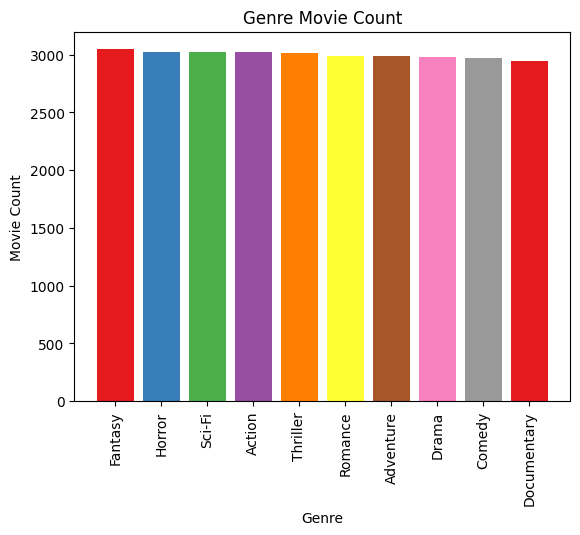

In [10]:
plt.bar(df_genre.index,df_genre,color=palette)
plt.xlabel('Genre')
plt.ylabel('Movie Count')
plt.title('Genre Movie Count')
plt.xticks(rotation=90)
plt.show()

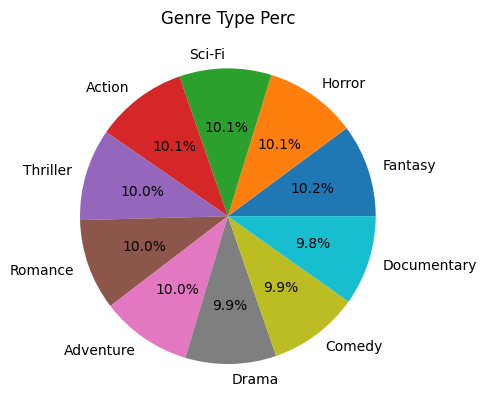

In [11]:
plt.pie(df_genre,autopct='%1.1f%%',labels=df_genre.index)
plt.title("Genre Type Perc")
plt.show()

In [12]:
yearly_movie=df['year'].value_counts()

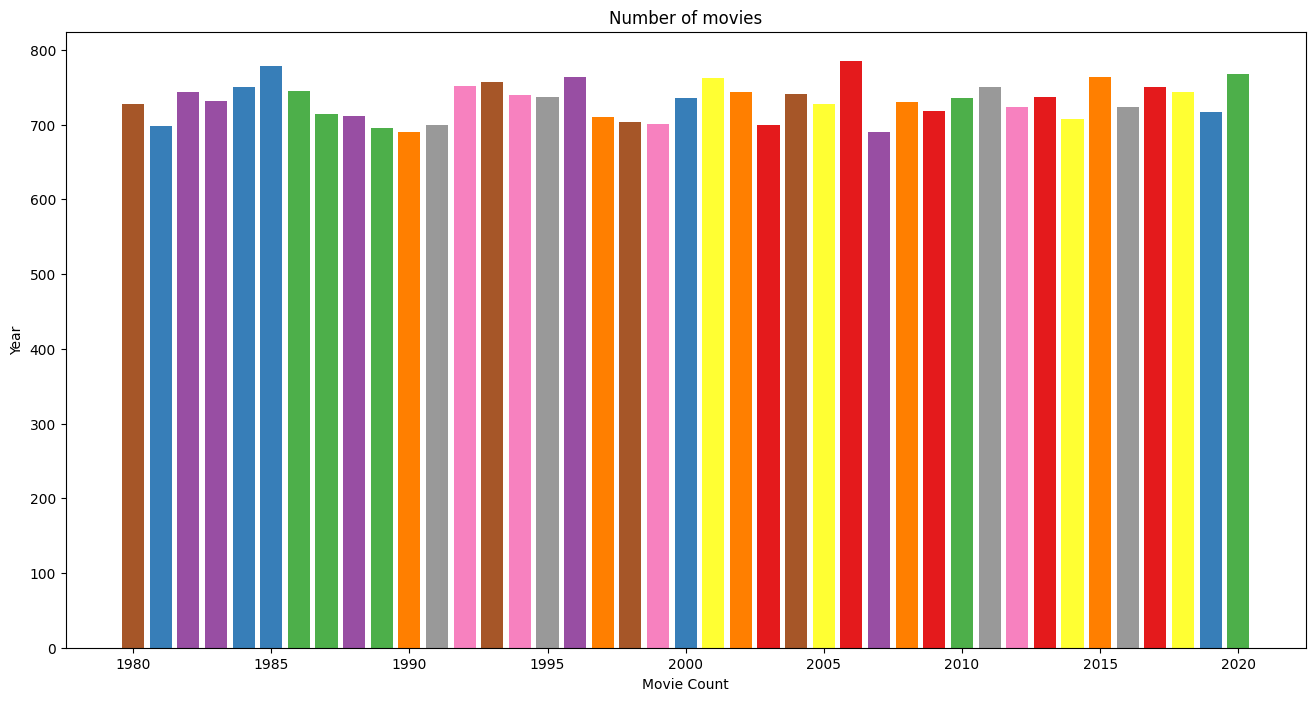

In [13]:
plt.figure(figsize=(16, 8))
plt.bar(yearly_movie.index,yearly_movie,color=palette)
plt.ylabel('Year')
plt.xlabel('Movie Count')
plt.title('Number of movies')
plt.show()

In [14]:
grouped_genre=df.groupby('year')['Genre'].value_counts().reset_index()
grouped_genre.sort_values(by='count',ascending=False)

,year,Genre,count
140,1994,Horror,101
370,2017,Drama,100
260,2006,Action,99
240,2004,Drama,99
150,1995,Action,97
...,...,...,...
39,1983,Horror,54
99,1989,Sci-Fi,54
79,1987,Sci-Fi,53
19,1981,Drama,52


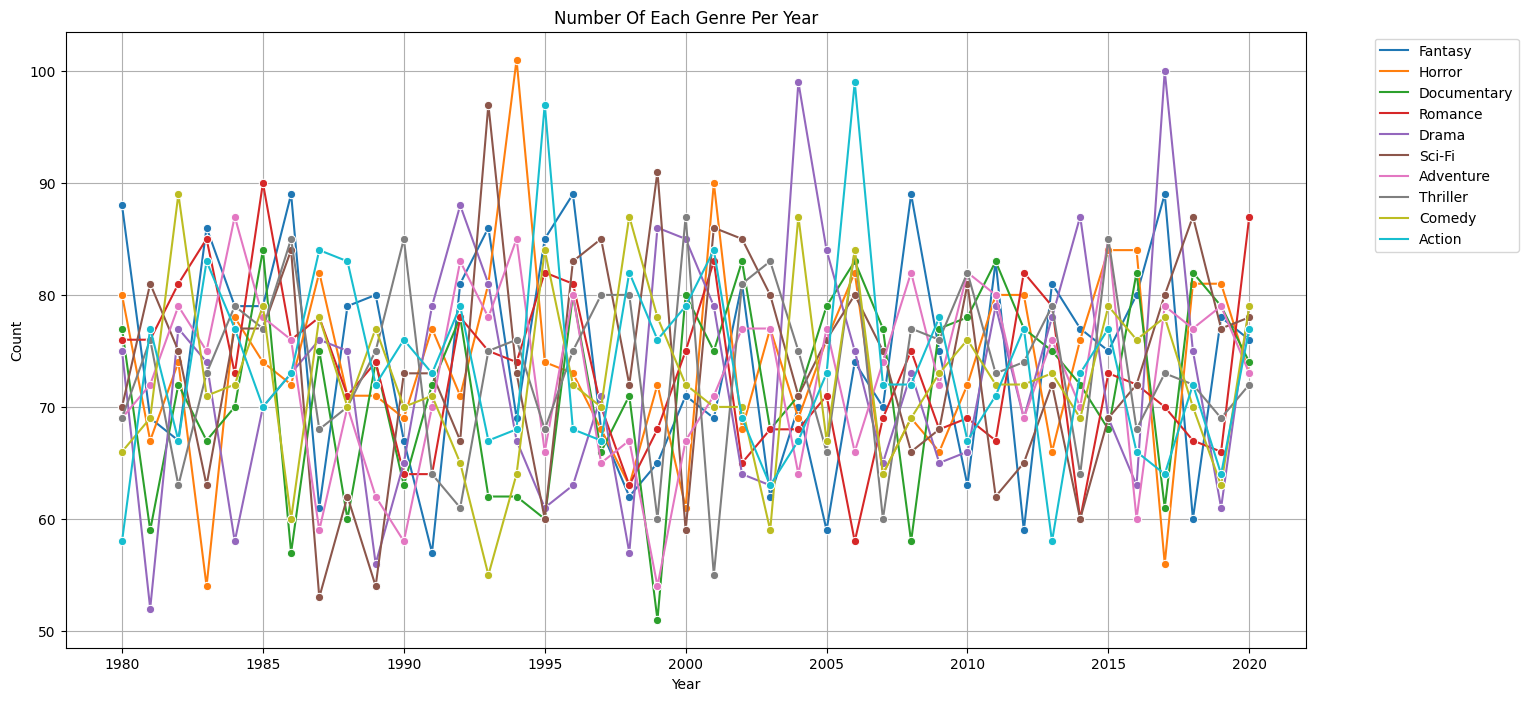

In [15]:
plt.figure(figsize=(16, 8))
sns.lineplot(data=grouped_genre, x="year", y="count", hue="Genre",marker='o')
plt.xlabel('Year')
plt.ylabel('Count')
plt.title('Number Of Each Genre Per Year')
plt.legend(bbox_to_anchor=(1.05, 1))
plt.grid()
plt.show()

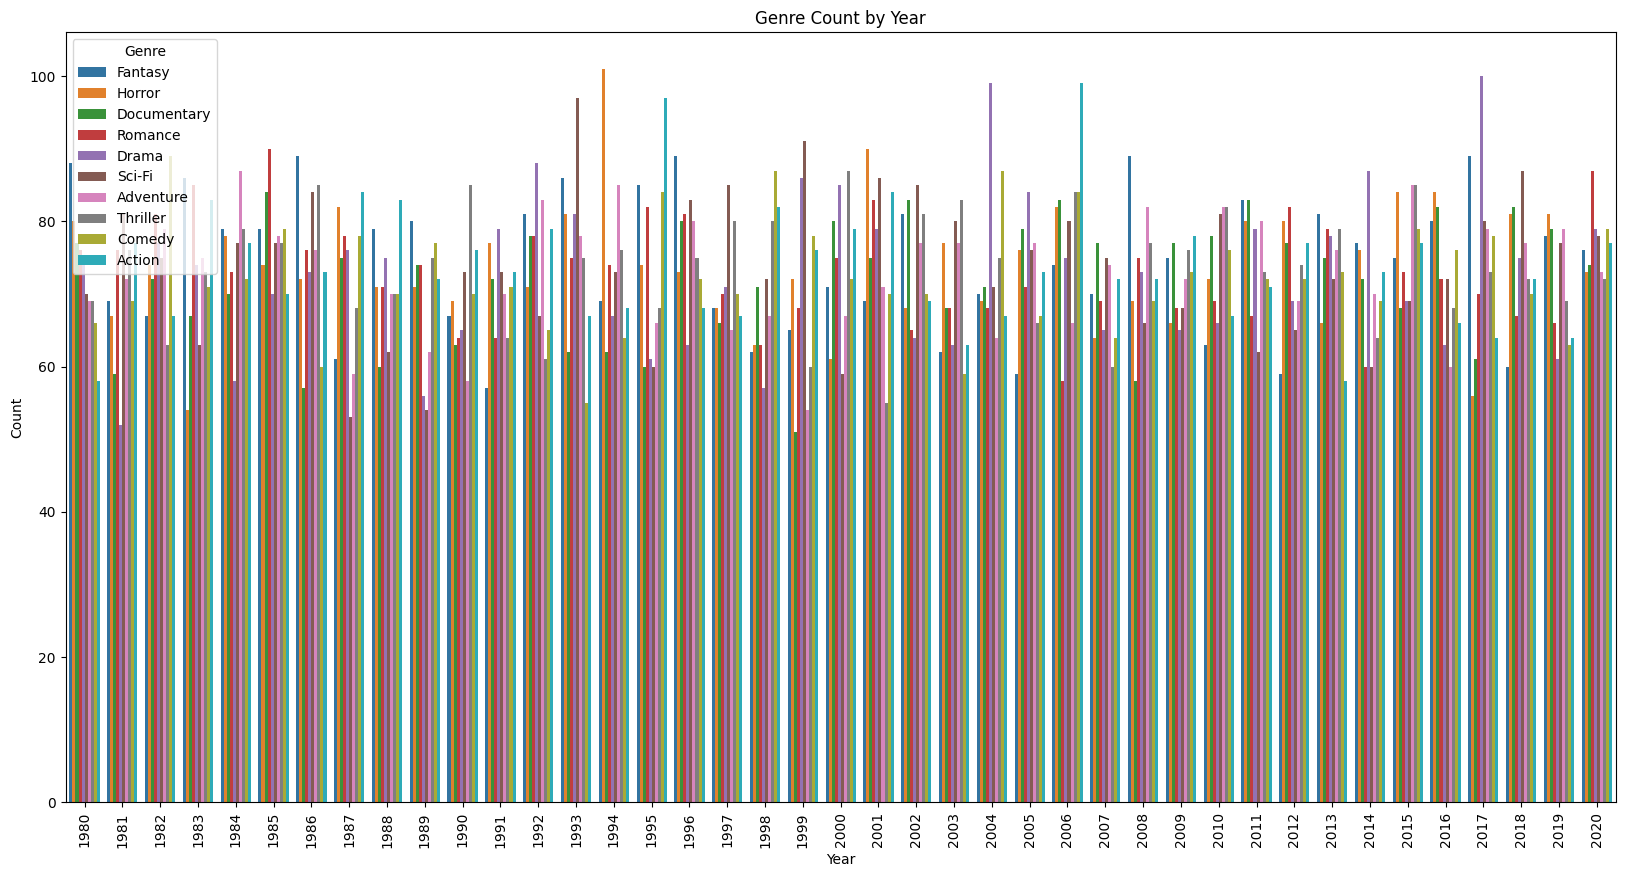

In [16]:
plt.figure(figsize=(20,10))
sns.barplot(x='year', y='count', hue='Genre', data=grouped_genre)
plt.title('Genre Count by Year')
plt.xlabel('Year')
plt.ylabel('Count')
plt.xticks(rotation=90)
plt.show()

In [17]:
top_director=df.groupby('Director')['Genre'].count().sort_values(ascending=False).head(11)
top_director

Director
James Smith          13
Christopher Smith    12
Lisa Smith           11
David Smith          10
Michael Miller       10
Michael Smith        10
John Smith           10
Jennifer Smith       10
Jessica Johnson       9
David Davis           9
William Williams      9
Name: Genre, dtype: int64

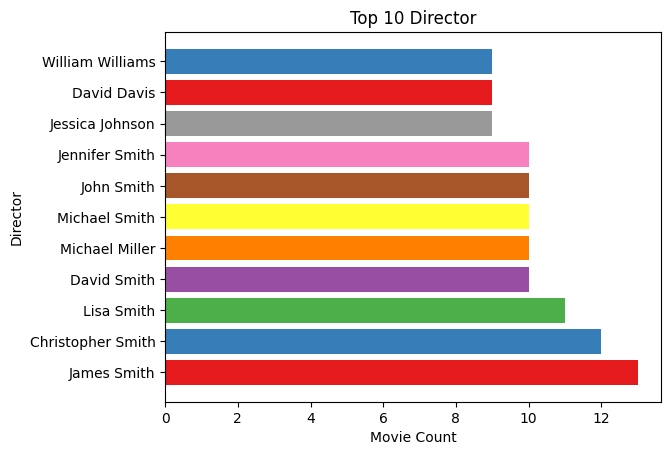

In [18]:
plt.barh(top_director.index,top_director,color=palette)
plt.ylabel('Director')
plt.xlabel('Movie Count')
plt.title('Top 10 Director')
plt.show()

In [19]:
director_genre=df.groupby('Director')['Genre'].value_counts().reset_index().sort_values(by='count',ascending=False).head(10)
director_genre

,Director,Genre,count
12739,Jennifer Williams,Adventure,4
7420,David Smith,Documentary,4
11487,James Smith,Action,4
23590,Richard Jones,Documentary,3
2107,Anthony Hall,Sci-Fi,3
20550,Michael Williams,Documentary,3
22660,Paul Williams,Action,3
7176,David Davis,Action,3
11532,James Williams,Documentary,3
29231,William White,Adventure,3


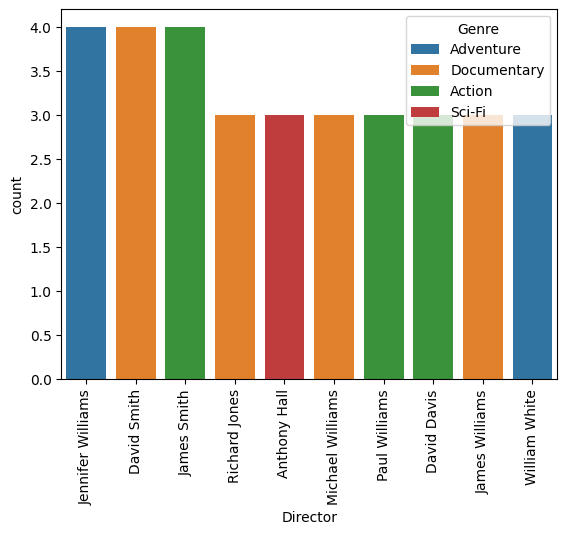

In [20]:
sns.barplot(director_genre,x='Director',y='count',hue='Genre',dodge=False)
plt.xticks(rotation=90)
plt.show()

In [21]:
top_rating_by_year=df.groupby('year')['Rating'].value_counts().reset_index()
top_rating_by_year = top_rating_by_year.sort_values(['Rating', 'count'], ascending=[False, False]).head(41)
top_rating_by_year

,year,Rating,count
3593,2019,10.0,8
609,1986,10.0,7
1699,1998,10.0,7
2435,2006,10.0,7
1440,1995,10.0,6
2804,2010,10.0,6
538,1985,10.0,5
719,1987,10.0,5
810,1988,10.0,5
1260,1993,10.0,5


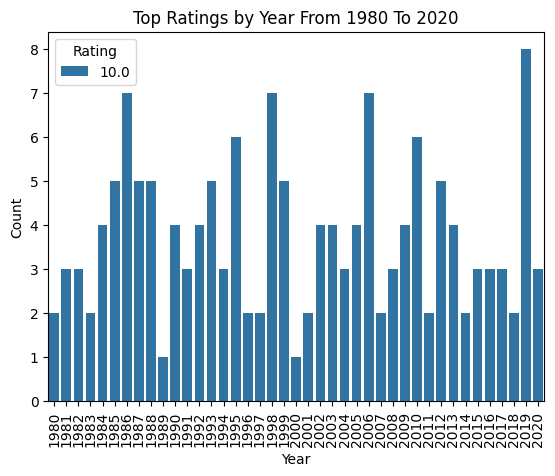

In [22]:
sns.barplot(x='year', y='count', hue='Rating', data=top_rating_by_year)
plt.title('Top Ratings by Year From 1980 To 2020')
plt.xlabel('Year')
plt.ylabel('Count')
plt.xticks(rotation=90)
plt.show()

In [23]:
top_rating_by_genre=df.groupby('Genre')['Rating'].value_counts().reset_index()
top_rating_by_genre = top_rating_by_genre.sort_values(['Rating', 'count'], ascending=[False, False]).head(10)
top_rating_by_genre 

,Genre,Rating,count
88,Action,10.0,23
271,Comedy,10.0,21
908,Thriller,10.0,19
181,Adventure,10.0,17
454,Drama,10.0,16
544,Fantasy,10.0,16
727,Romance,10.0,15
363,Documentary,10.0,10
818,Sci-Fi,10.0,10
636,Horror,10.0,6


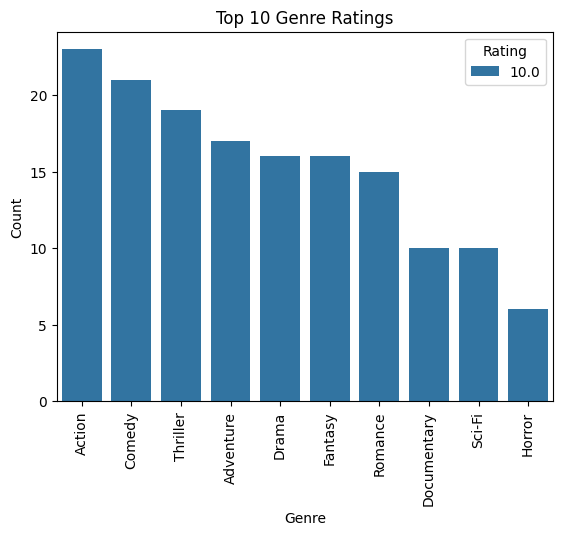

In [24]:
sns.barplot(x='Genre', y='count', hue='Rating', data=top_rating_by_genre)
plt.title('Top 10 Genre Ratings')
plt.xlabel('Genre')
plt.ylabel('Count')
plt.xticks(rotation=90)
plt.show()

In [25]:
top_duration_by_year=df.groupby('year')['Duration'].value_counts().reset_index()
top_duration_by_year=top_duration_by_year.sort_values(['Duration', 'count'], ascending=[False, False]).head(41)
top_duration_by_year

,year,Duration,count
849,1987,180,12
2419,2000,180,11
2786,2003,180,10
20,1980,180,9
2185,1998,180,9
2915,2004,180,9
3512,2009,180,9
4484,2017,180,9
1483,1992,180,8
1600,1993,180,8


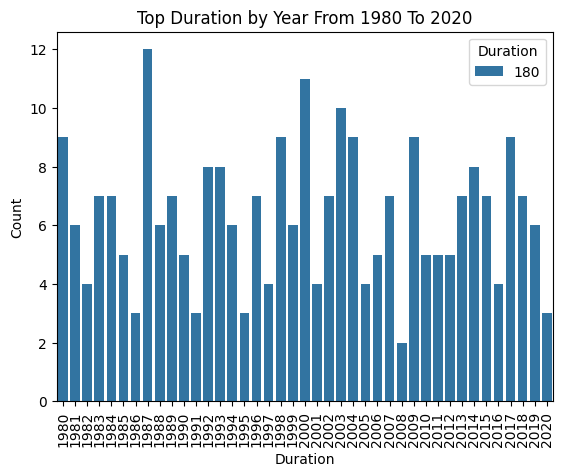

In [26]:
sns.barplot(x='year', y='count', hue='Duration', data=top_duration_by_year)
plt.title('Top Duration by Year From 1980 To 2020')
plt.xlabel('Duration')
plt.ylabel('Count')
plt.xticks(rotation=90)
plt.show()

In [27]:
duration=df['Duration'].value_counts().sort_values(ascending=False)
duration.head(10)

Duration
70     287
173    286
84     282
111    282
131    278
148    277
92     277
135    277
133    272
115    271
Name: count, dtype: int64

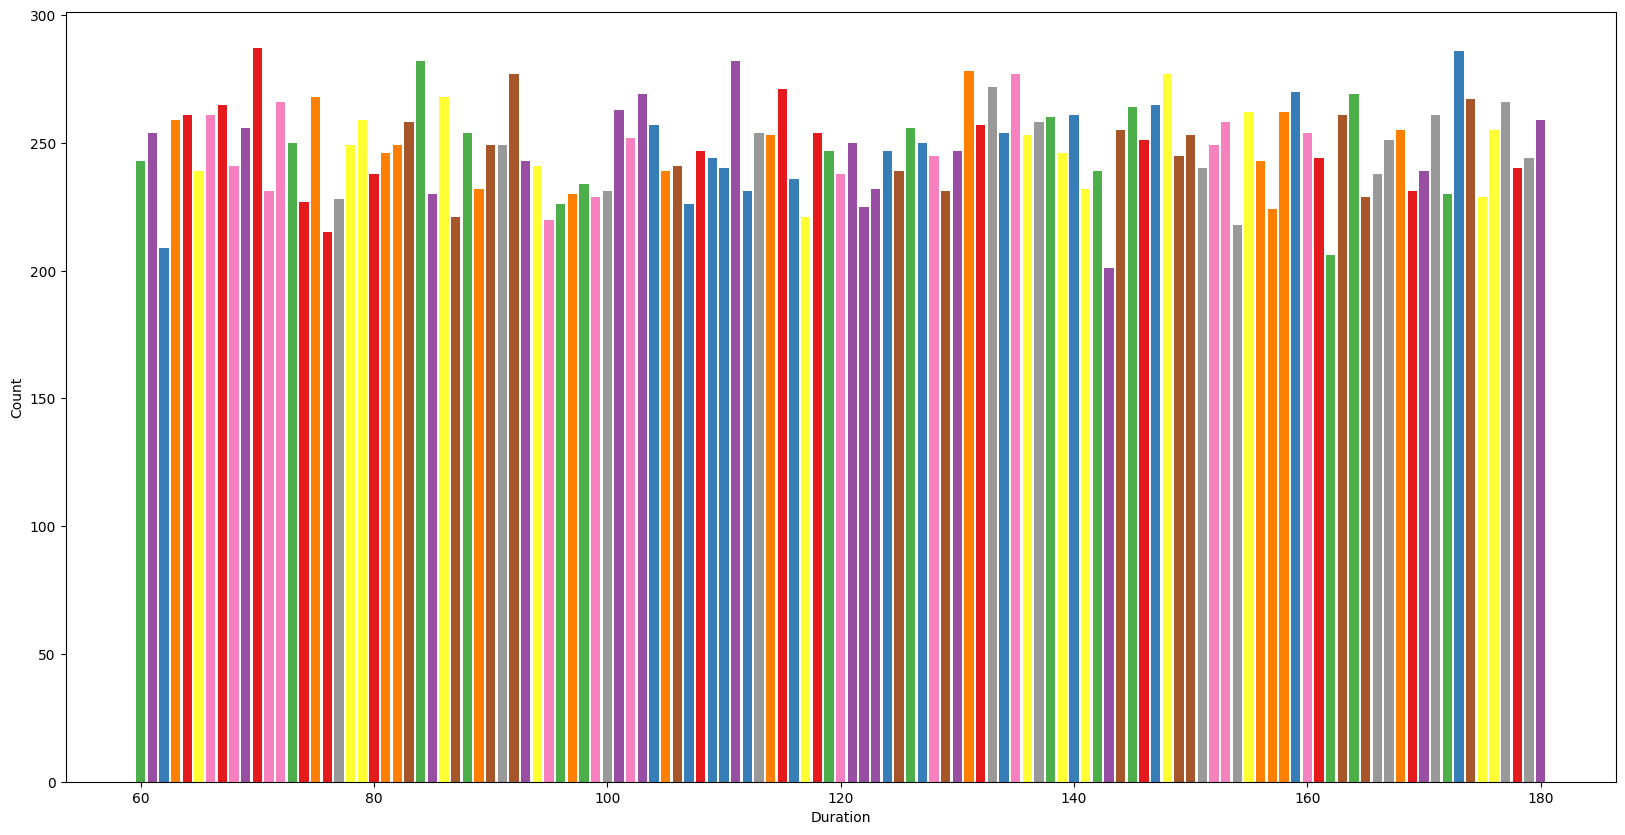

In [28]:
plt.figure(figsize=(20,10))
plt.bar(duration.index,duration,color=palette)
plt.xlabel('Duration')
plt.ylabel('Count')
plt.show()

In [29]:
top_duration_by_genre=df.groupby(['Genre','Duration'])['Duration'].value_counts().reset_index()
top_duration_by_genre=top_duration_by_genre.sort_values(by='count',ascending=False).head(10)
top_duration_by_genre

,Genre,Duration,count
63,Action,123,41
572,Drama,148,40
927,Romance,140,40
1071,Sci-Fi,163,40
525,Drama,101,39
561,Drama,137,38
736,Horror,70,38
172,Adventure,111,38
548,Drama,124,37
1160,Thriller,131,37


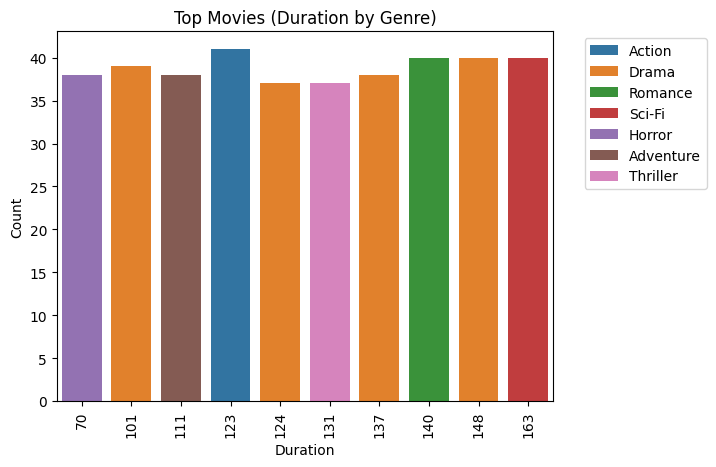

In [30]:
sns.barplot(x='Duration', y='count', hue='Genre', data=top_duration_by_genre,dodge=False)
plt.title('Top Movies (Duration by Genre)')
plt.xlabel('Duration')
plt.ylabel('Count')
plt.xticks(rotation=90)
plt.legend(bbox_to_anchor=(1.05, 1))
plt.show()

In [31]:
genre_counts=top_duration_by_genre.groupby('Genre')['count'].sum().reset_index()
genre_counts=genre_counts.sort_values(by='count',ascending=False)
counts = genre_counts['count'].tolist()
labels = genre_counts['Genre'].tolist()
genre_counts


,Genre,count
2,Drama,154
0,Action,41
4,Romance,40
5,Sci-Fi,40
1,Adventure,38
3,Horror,38
6,Thriller,37


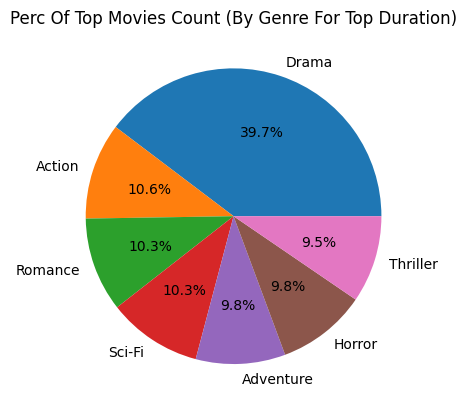

In [32]:
plt.pie(counts, autopct='%1.1f%%', labels=labels)
plt.title("Perc Of Top Movies Count (By Genre For Top Duration)")
plt.show()

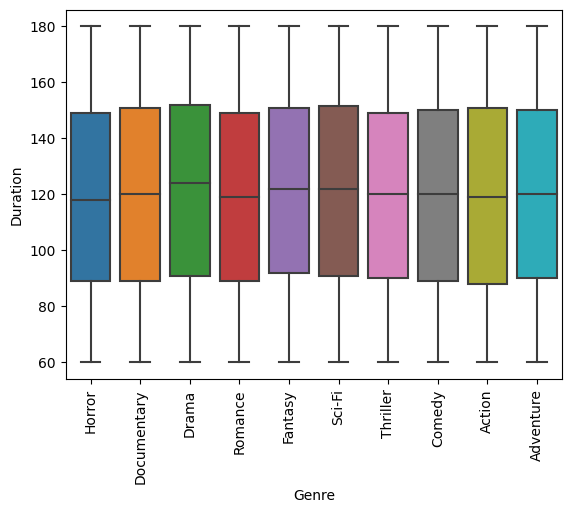

In [33]:
sns.boxplot(data=df, x="Genre", y="Duration")
plt.xlabel('Genre')
plt.ylabel('Duration')
plt.xticks(rotation=90)
plt.show()

# **Some Conclusions.**

**1- We see that the number of issues is close to each other, and this indicates diversity in viewing**

**2- Fantasy is a favorite for all ages, so it is the most popular version**

**3- Action is the most rated and got a full score of 10/10 with 23 films**

**4- The longest films are those that exceed three hours, and most of them were in 1987**

 **dont forget upvote**